### Nonlinear Option Pricing, Master 2 Probabilités et Finance, Sorbonne Université and École polytechnique
# Test Notebook

In this notebook, we demonstrate some typical uses of Python in the context of derivatives pricing. In particular, we provide some common numerical routines that you would need in the homework assigments. Please make sure the notebook runs to completion and produces expected numerical results and charts.

You need the following python packages installed on your computer to run this notebook:
<ul>
    <li>numpy</li>
    <li>scipy</li>
    <li>matplotlib</li>
    <li>tensorflow</li>
</ul>

This is not an homework assignment. There is nothing for you to turn in. The notebook is provided solely for your reference.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

### Black-Scholes Option Pricing Formula

In the Black-Scholes model, the price of an tradable asset $S_t$ is assumed to follow a geometric Brownian motion:

$$\frac{dS_t}{S_t}=\left(r-q\right)dt+\sigma dW_t$$

where $r$ is interest rate, $q$ is devidend yield, $\sigma$ is volatility, and $W_t$ is standard one-dimensional Brownian motion. Then the prices of vanilla call and put options are given by the following formulas:

$$\text{Price of Call}=S_0e^{-qT}N(d_1)-Ke^{-rT}N(d_2)\quad\text{and}\quad
\text{Price of Put}=Ke^{-rT}N(-d_2)-S_0e^{-qT}N(-d_1)$$

where $K$ is the strike and $T$ is the expiry of the option, and

$$d_1=\frac{1}{\sigma\sqrt{T}}\left[\log\frac{S_0}{K}+\left(r-q+\frac{1}{2}\sigma^2\right)T\right]
\quad\text{and}\quad d_2=d_1-\sigma\sqrt{T}$$

In [2]:
def blackscholes_price(K, T, S0, vol, r=0, q=0, callput='call'):
    """Compute the call/put option price in the Black-Scholes model
    
    Parameters
    ----------
    K: scalar or array_like
        The strike of the option.
    T: scalar or array_like
        The maturity of the option, expressed in years (e.g. 0.25 for 3-month and 2 for 2 years)
    S0: scalar or array_like
        The current price of the underlying asset.
    vol: scalar or array_like
        The implied Black-Scholes volatility.
    r: scalar or array_like
        The annualized risk-free interest rate, continuously compounded.
    q: scalar or array_like
        The annualized continuous dividend yield.
    callput: str
        Must be either 'call' or 'put'.

    Returns
    -------
    price: scalar or array_like
        The price of the option.

    Examples
    --------
    >>> blackscholes_price(95, 0.25, 100, 0.2, r=0.05, callput='put')
    1.5342604771222823
    """
    F = S0*np.exp((r-q)*T)
    v = vol*np.sqrt(T)
    d1 = np.log(F/K)/v + 0.5*v
    d2 = d1 - v
    try:
        opttype = {'call':1, 'put':-1}[callput.lower()]
    except:
        raise ValueError('The value of callput must be either "call" or "put".')
    price = opttype*(F*norm.cdf(opttype*d1)-K*norm.cdf(opttype*d2))*np.exp(-r*T)
    return price

In [3]:
# Compute the price of a European put option that expires in six months and has a strike price 95
# with current spot price 100, interest rate 5%, dividend yield 2%, Black-Scholes volatility 20%
blackscholes_price(K=95, T=0.5, S0=100, vol=0.2, r=0.05, q=0.02, callput='put')

2.808498696160873

Text(0, 0.5, 'Price')

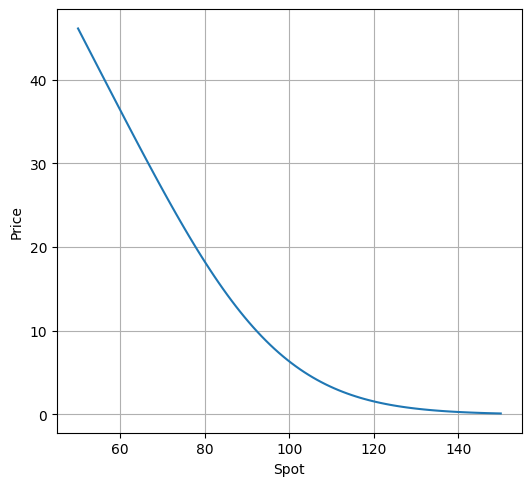

In [4]:
# Compute and plot the prices of European put options for an array of spot prices
spots = np.linspace(50, 150, 100)
prices = blackscholes_price(K=100, T=1, S0=spots, vol=0.2, r=0.05, q=0.02, callput='put')
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot(spots, prices)
ax.grid(True)
ax.set_xlabel('Spot')
ax.set_ylabel('Price')

In [5]:
# Compute the prices of European put options with a matrix of expiries and strikes, using numpy's broadcasting feature
Ks = np.array([90, 100, 110])
Ts = np.array([0.25, 0.5])
blackscholes_price(Ks, Ts[:, np.newaxis], S0=100, vol=0.2, r=0.05, q=0.02, callput='put')

array([[ 0.60914165,  3.59241775, 10.21821102],
       [ 1.44484885,  4.83364298, 10.86502029]])

### Monte Carlo Simulation in the Black-Scholes Model

In [6]:
def blackscholes_mc(ts, n_paths, S0, vol, r, q):
    """Generate Monte-Carlo paths in Black-Scholes model.

    Parameters
    ----------
    ts: array_like
        The time steps of the simualtion
    n_paths: int
        the number of paths to simulate
    S0: scalar
        The spot price of the underlying security.
    vol: scalar
        The implied Black-Scholes volatility.
    r: scalar
        The annualized risk-free interest rate, continuously compounded.
    q: scalar
        The annualized continuous dividend yield.

    Returns
    -------
    paths: 2D ndarray of shape (len(ts), n_paths)
        The Monte-Carlo paths.
    """
    paths = np.full((len(ts), n_paths), np.nan, dtype=float)
    paths[0] = S0
    for i in range(len(ts)-1):
        dt = ts[i+1] - ts[i]
        dW = np.sqrt(dt)*np.random.randn(n_paths)
        paths[i+1] = paths[i] * np.exp((r-q-1/2*vol**2)*dt + vol*dW)
    return paths

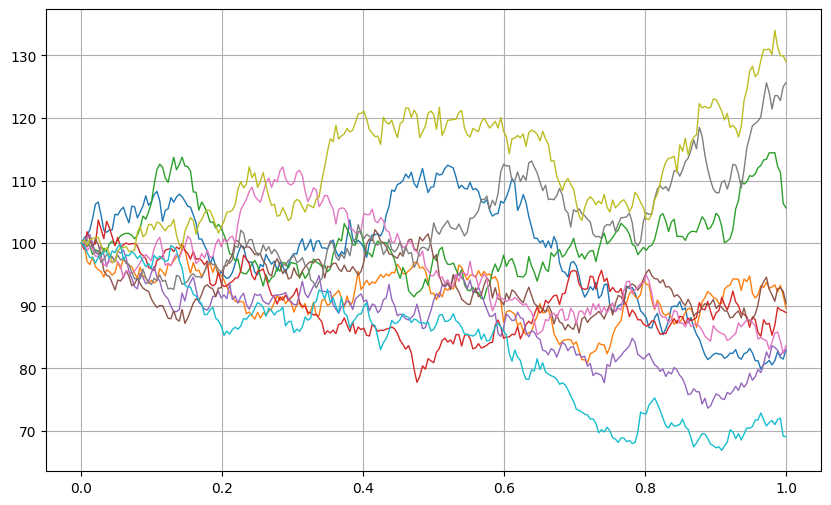

In [7]:
ts = np.linspace(0, 1, 253)
paths = blackscholes_mc(ts=ts, n_paths=10, S0=100, vol=0.2, r=0.05, q=0.02)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ts, paths, lw=1)
ax.grid(True)

In [8]:
# Use Monte Carlo simulation to price an European put option
K = 95
T = 0.5
r = 0.05
q = 0.02
vol = 0.2
ts = np.linspace(0, T, int(round(T*252))+1) # daily timestep
paths = blackscholes_mc(ts=ts, n_paths=100000, S0=100, vol=vol, r=r, q=q)
np.mean(np.maximum(K-paths[-1], 0))*np.exp(-r*T)

2.8078615184910167

### Black-Scholes Implied Volatility

In [9]:
# all inputs must be scalar
def blackscholes_impv_scalar(K, T, S0, value, r=0, q=0, callput='call', tol=1e-6, maxiter=500):
    """Compute implied volatility in Black-Scholes model
    
    Parameters
    ----------
    K: scalar
        The strike of the option.
    T: scalar
        The maturity of the option.
    S0: scalar
        The current price of the underlying asset.
    value: scalar
        The value of the option
    callput: str
        Must be either 'call' or 'put'

    Returns
    -------
    vol: scalar
        The implied vol of the option.
    """
    if (K <= 0) or (T <= 0) or (S0 <= 0):
        return np.nan
    F = S0*np.exp((r-q)*T)
    K = K/F
    value = value*np.exp(r*T)/F
    try:
        opttype = {'call':1, 'put':-1}[callput.lower()]
    except:
        raise ValueError('The value of callput must be either "call" or "put".')
    # compute the time-value of the option
    value -= max(opttype * (1 - K), 0)
    if value < 0:
        return np.nan
    if (value == 0):
        return 0
    j = 1
    p = np.log(K)
    if K >= 1:
        x0 = np.sqrt(2 * p)
        x1 = x0 - (0.5 - K * norm.cdf(-x0) - value) * np.sqrt(2*np.pi)
        while (abs(x0 - x1) > tol*np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p/x1+0.5*x1
            x1 = x1 - (norm.cdf(d1) - K*norm.cdf(d1-x1)-value)*np.sqrt(2*np.pi)*np.exp(0.5*d1**2)
            j += 1
        return x1 / np.sqrt(T)
    else:
        x0 = np.sqrt(-2 * p)
        x1 = x0 - (0.5*K-norm.cdf(-x0)-value)*np.sqrt(2*np.pi)/K
        while (abs(x0-x1) > tol*np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p/x1+0.5*x1
            x1 = x1-(K*norm.cdf(x1-d1)-norm.cdf(-d1)-value)*np.sqrt(2*np.pi)*np.exp(0.5*d1**2)
            j += 1
        return x1 / np.sqrt(T)

# vectorized version
blackscholes_impv = np.vectorize(blackscholes_impv_scalar, excluded={'callput', 'tol', 'maxiter'})

In [10]:
# Example
blackscholes_impv(K=95, T=0.25, S0=100, value=1.5, callput='put')

array(0.17681311)

### Tensorflow Examples

In this example, we use a neural network to estimate the price of a $T$-maturity European call option at an intermediate time $0<t<T$. The underlying asset price $S_t$ is assumed to follow a Black-Scholes model. The price of the call option at $t$ is then a (nonlinear) function of $S_{t}$. In particular, this price function $u(t,S_t)$ is the conditional expectation of the discounted final payoff at $T$ given the spot value at time $t$, i.e.,

$$u(t, S)=\mathbb{E}^{\mathbb{Q}}\left[\left.e^{-(T-t)}\left(S_T-K\right)^+\right\vert S_t=S\right].$$

A feed-forward neural network is used to estimate this conditional expectation. We simulate training paths in the Black-Scholes model and fit the network with the mean squared error (MSE) loss function to the simulated data.

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [12]:
# verify your tensorflow version
tf.__version__

'2.10.1'

#### Preparing Training Data

In [13]:
S0 = 100.
vol = 0.2
r = 0.05
q = 0.02
K = S0
ts = np.linspace(0, 1, 13)

In [14]:
# simulate training paths
n_paths = 100000
paths = blackscholes_mc(ts=ts, n_paths=n_paths, S0=S0, vol=vol, r=r, q=q)

In [15]:
# estimate price function at t = ts[j]
j = 6
X_train_full = paths[j]
# normalize the inputs
mX = np.mean(X_train_full)
sX = np.std(X_train_full)
X_train_full = ((X_train_full - mX) / sX)[:, np.newaxis]
Y_train_full = (np.maximum(paths[-1]-K, 0)*np.exp(-r*(ts[-1]-ts[j])))[:, np.newaxis]
# split the dataset to a training and a validation set
train_size = int(len(X_train_full)*0.75)
X_train = X_train_full[:train_size]
X_valid = X_train_full[train_size:]
Y_train = Y_train_full[:train_size]
Y_valid = Y_train_full[train_size:]

#### Creating and Compiling the Model

In [16]:
model = keras.models.Sequential([
    keras.layers.Dense(20, activation='relu', input_shape=[1]),
    keras.layers.Dense(20, activation='relu'),
    keras.layers.Dense(1)])
model.compile(loss=keras.losses.MeanSquaredError(), optimizer=keras.optimizers.Adam(learning_rate=0.001))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 20)                40        
                                                                 
 dense_1 (Dense)             (None, 20)                420       
                                                                 
 dense_2 (Dense)             (None, 1)                 21        
                                                                 
Total params: 481
Trainable params: 481
Non-trainable params: 0
_________________________________________________________________


#### Training the Model

In [17]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=6, min_delta=5e-3, restore_best_weights=True)
model.fit(X_train, Y_train, epochs=50, batch_size=128, validation_data=(X_valid, Y_valid), verbose=True, callbacks=[early_stopping_cb])

Epoch 1/50
586/586 [==============================] - 1s 1ms/step - loss: 148.8398 - val_loss: 116.7697
Epoch 2/50
586/586 [==============================] - 1s 946us/step - loss: 115.9789 - val_loss: 116.6527
Epoch 3/50
586/586 [==============================] - 1s 937us/step - loss: 115.8165 - val_loss: 116.4052
Epoch 4/50
586/586 [==============================] - 1s 932us/step - loss: 115.7277 - val_loss: 116.2856
Epoch 5/50
586/586 [==============================] - 1s 928us/step - loss: 115.7071 - val_loss: 116.3157
Epoch 6/50
586/586 [==============================] - 1s 931us/step - loss: 115.6877 - val_loss: 116.3021
Epoch 7/50
586/586 [==============================] - 1s 937us/step - loss: 115.6834 - val_loss: 116.2475
Epoch 8/50
586/586 [==============================] - 1s 929us/step - loss: 115.6517 - val_loss: 116.7929
Epoch 9/50
586/586 [==============================] - 1s 932us/step - loss: 115.6666 - val_loss: 116.2431
Epoch 10/50
586/586 [===========================

#### Evaluating the Model

We compare the neural network predictions against the exact prices given by the Black-Scholes formula.

7/7 [==============================] - 0s 831us/step


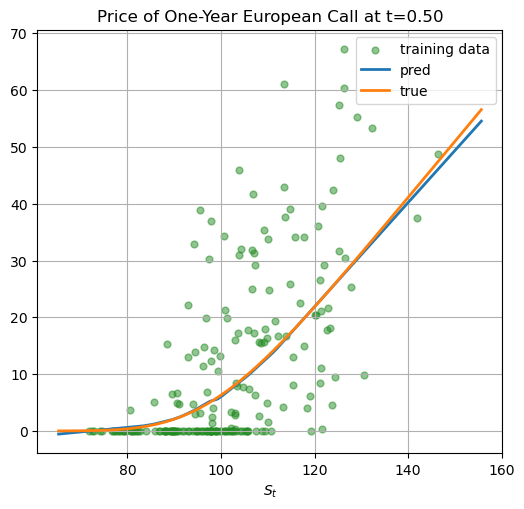

In [18]:
fig, ax = plt.subplots(figsize=(6, 5.5))
x = np.linspace(*np.percentile(paths[j], [0.1, 99.9]), num=200)
y_pred = model.predict((x-mX)/sX)[:, 0]
y_true = blackscholes_price(K, ts[-1]-ts[j], x, vol=vol, r=r, q=q, callput='call')
ax.scatter(X_train[:200, 0]*sX+mX, Y_train[:200, 0], s=24, color='forestgreen', alpha=0.5, label='training data')
ax.plot(x, y_pred, lw=2, label='pred')
ax.plot(x, y_true, lw=2, label='true')
ax.legend(loc=0)
ax.set_title('Price of One-Year European Call at t={:.2f}'.format(ts[j]))
ax.set_xlabel('$S_t$')
ax.grid(True)